# PVOL vs DVOL — Historical Overview (Jul 2025 – Feb 2026)
Loads precomputed data from `backend/data/history.json` and visualises the full 8-month record.

In [1]:
%matplotlib inline
import json, pathlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.patches as mpatches
import warnings
warnings.filterwarnings('ignore')

# ── Load data ────────────────────────────────────────────────────────────────
DATA = pathlib.Path('../../backend/data/history.json')
df = pd.DataFrame(json.loads(DATA.read_text()))
df['date'] = pd.to_datetime(df['date'])
df = df.sort_values('date').reset_index(drop=True)

# Month order for display
MONTH_ORDER = [
    'july-2025','august-2025','september-2025','october-2025',
    'november-2025','december-2025','january-2026','february-2026',
]
MONTH_LABELS = [m.replace('-', ' ').title() for m in MONTH_ORDER]

# Color palette — one per month
COLORS = [
    '#4e79a7','#f28e2b','#e15759','#76b7b2',
    '#59a14f','#edc948','#b07aa1','#ff9da7',
]
COLOR_MAP = dict(zip(MONTH_ORDER, COLORS))
df['color'] = df['contract_month'].map(COLOR_MAP)

# Month boundary dates (first date of each month in the dataset)
boundaries = df.groupby('contract_month')['date'].min().reindex(MONTH_ORDER).dropna()

print(f"Loaded {len(df)} records  |  {df['date'].min().date()} to {df['date'].max().date()}")
print(df.groupby('contract_month').size().reindex(MONTH_ORDER).to_string())


Loaded 190 records  |  2025-07-01 to 2026-02-22
contract_month
july-2025         25
august-2025       24
september-2025    23
october-2025      24
november-2025     23
december-2025     25
january-2026      24
february-2026     22


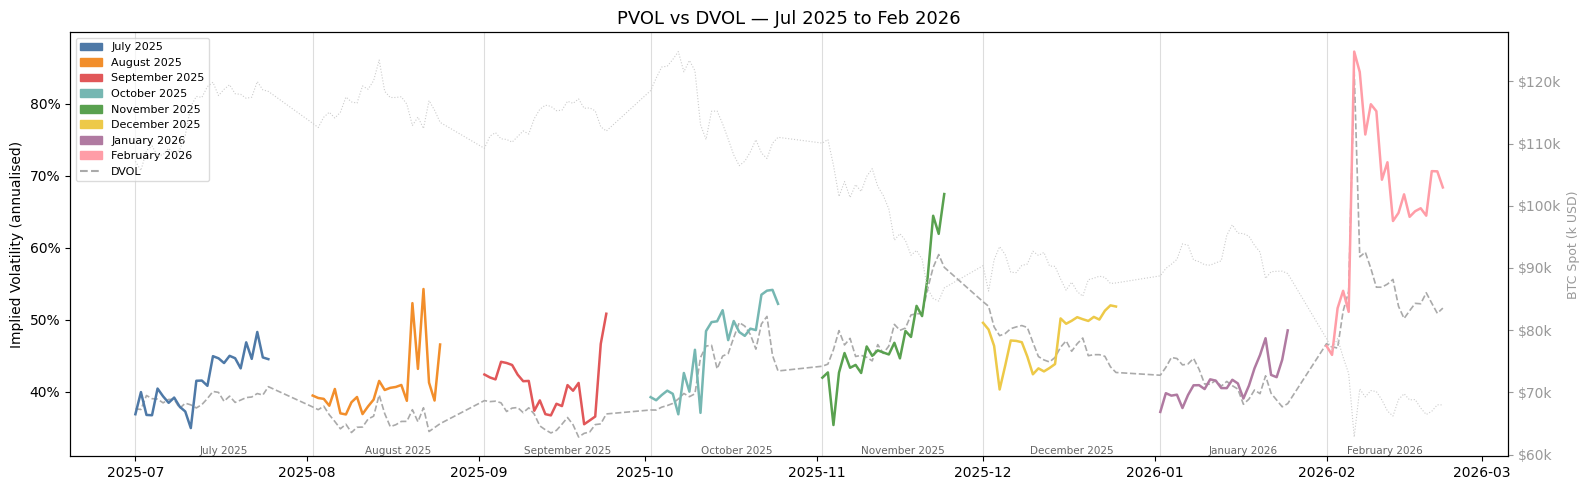

In [2]:

# ── Chart 1 — Full timeline: PVOL vs DVOL ────────────────────────────────────
fig, ax1 = plt.subplots(figsize=(16, 5))
ax2 = ax1.twinx()

# DVOL — dashed gray (plot first so colored PVOL sits on top)
ax1.plot(df['date'], df['dvol'], color='#aaaaaa', linewidth=1.2,
         linestyle='--', label='DVOL', zorder=2)

# PVOL — solid, colored by contract month
for month in MONTH_ORDER:
    sub = df[df['contract_month'] == month]
    if sub.empty:
        continue
    ax1.plot(sub['date'], sub['pvol'], color=COLOR_MAP[month],
             linewidth=1.8, label=month, zorder=3)

# BTC spot on right axis
ax2.plot(df['date'], df['spot'] / 1000, color='#cccccc', linewidth=0.8,
         linestyle=':', zorder=1)
ax2.set_ylabel('BTC Spot (k USD)', color='#999999', fontsize=9)
ax2.tick_params(axis='y', colors='#999999')
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:.0f}k'))

# Vertical month separators
for dt in boundaries.values:
    ax1.axvline(dt, color='#dddddd', linewidth=0.8, zorder=0)

# Month labels centered in each band
for i, (month, start_dt) in enumerate(boundaries.items()):
    end_dt = boundaries.iloc[i + 1] if i + 1 < len(boundaries) else df['date'].max()
    mid = start_dt + (end_dt - start_dt) / 2
    ax1.text(mid, ax1.get_ylim()[0], MONTH_LABELS[MONTH_ORDER.index(month)],
             ha='center', va='bottom', fontsize=7.5, color='#666666')

ax1.set_xlabel('')
ax1.set_ylabel('Implied Volatility (annualised)', fontsize=10)
ax1.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1, decimals=0))
ax1.set_title('PVOL vs DVOL — Jul 2025 to Feb 2026', fontsize=13)

# Legend: one entry per month + DVOL
handles = [mpatches.Patch(color=COLOR_MAP[m], label=MONTH_LABELS[MONTH_ORDER.index(m)])
           for m in MONTH_ORDER if m in df['contract_month'].values]
handles.append(plt.Line2D([0], [0], color='#aaaaaa', linestyle='--', label='DVOL'))
ax1.legend(handles=handles, fontsize=8, loc='upper left', framealpha=0.7)

plt.tight_layout()
plt.show()


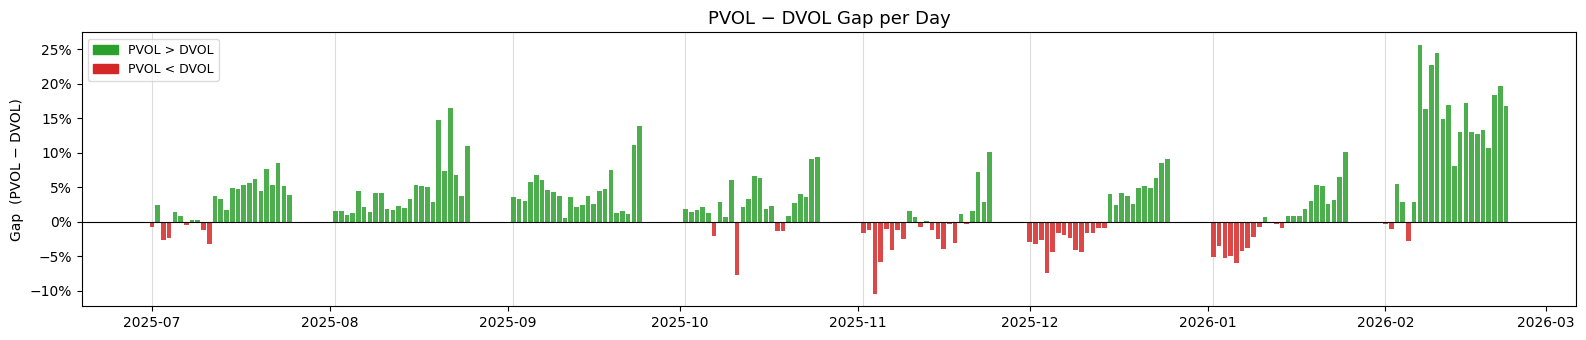

In [3]:

# ── Chart 2 — Gap (PVOL − DVOL) bar chart ────────────────────────────────────
fig, ax = plt.subplots(figsize=(16, 3.5))

colors = ['#2ca02c' if g >= 0 else '#d62728' for g in df['gap']]
ax.bar(df['date'], df['gap'], color=colors, width=0.8, alpha=0.85)
ax.axhline(0, color='black', linewidth=0.8)

for dt in boundaries.values:
    ax.axvline(dt, color='#dddddd', linewidth=0.8, zorder=0)

ax.set_ylabel('Gap  (PVOL − DVOL)', fontsize=10)
ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1, decimals=0))
ax.set_title('PVOL − DVOL Gap per Day', fontsize=13)

green_patch = mpatches.Patch(color='#2ca02c', label='PVOL > DVOL')
red_patch   = mpatches.Patch(color='#d62728', label='PVOL < DVOL')
ax.legend(handles=[green_patch, red_patch], fontsize=9, loc='upper left', framealpha=0.7)

plt.tight_layout()
plt.show()


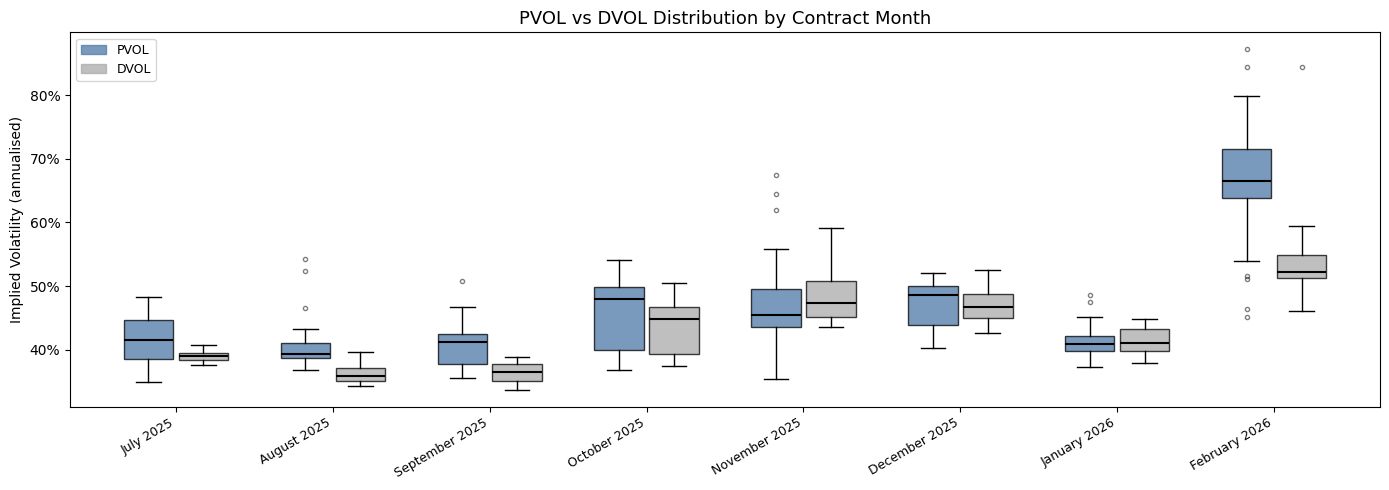

In [4]:

# ── Chart 3 — Per-month box plots ────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 5))

pvol_by_month = [df[df['contract_month'] == m]['pvol'].dropna().values for m in MONTH_ORDER]
dvol_by_month = [df[df['contract_month'] == m]['dvol'].dropna().values for m in MONTH_ORDER]

n = len(MONTH_ORDER)
x = np.arange(n)
width = 0.35

bp1 = ax.boxplot(pvol_by_month, positions=x - width/2, widths=width*0.9,
                 patch_artist=True, medianprops=dict(color='black', linewidth=1.5),
                 boxprops=dict(facecolor='#4e79a7', alpha=0.75),
                 whiskerprops=dict(linewidth=1), capprops=dict(linewidth=1),
                 flierprops=dict(marker='o', markersize=3, alpha=0.5))
bp2 = ax.boxplot(dvol_by_month, positions=x + width/2, widths=width*0.9,
                 patch_artist=True, medianprops=dict(color='black', linewidth=1.5),
                 boxprops=dict(facecolor='#aaaaaa', alpha=0.75),
                 whiskerprops=dict(linewidth=1), capprops=dict(linewidth=1),
                 flierprops=dict(marker='o', markersize=3, alpha=0.5))

ax.set_xticks(x)
ax.set_xticklabels(MONTH_LABELS, rotation=30, ha='right', fontsize=9)
ax.set_ylabel('Implied Volatility (annualised)', fontsize=10)
ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1, decimals=0))
ax.set_title('PVOL vs DVOL Distribution by Contract Month', fontsize=13)

pvol_patch = mpatches.Patch(color='#4e79a7', alpha=0.75, label='PVOL')
dvol_patch = mpatches.Patch(color='#aaaaaa', alpha=0.75, label='DVOL')
ax.legend(handles=[pvol_patch, dvol_patch], fontsize=9)

plt.tight_layout()
plt.show()


In [5]:

# ── Stats table ───────────────────────────────────────────────────────────────
stats = []
for month in MONTH_ORDER:
    sub = df[df['contract_month'] == month]
    if sub.empty:
        continue
    pvol = sub['pvol'].dropna()
    dvol = sub['dvol'].dropna()
    gap  = sub['gap'].dropna()
    stats.append({
        'contract_month':       month,
        'days':                 len(sub),
        'pvol_mean':            f"{pvol.mean():.1%}",
        'dvol_mean':            f"{dvol.mean():.1%}",
        'gap_mean':             f"{gap.mean():+.1%}",
        'gap_max':              f"{gap.max():+.1%}",
        'days_pvol_above_dvol': int((sub['gap'] > 0).sum()),
    })

stats_df = pd.DataFrame(stats).set_index('contract_month')
print(stats_df.to_string())


                days pvol_mean dvol_mean gap_mean gap_max  days_pvol_above_dvol
contract_month                                                                 
july-2025         25     41.5%     38.9%    +2.6%   +8.5%                    19
august-2025       24     40.9%     36.2%    +4.6%  +16.5%                    24
september-2025    23     40.8%     36.4%    +4.4%  +13.9%                    23
october-2025      24     46.0%     43.6%    +2.4%   +9.3%                    20
november-2025     23     48.0%     48.7%    -0.6%  +10.2%                     8
december-2025     25     47.4%     46.8%    +0.6%   +9.2%                    11
january-2026      24     41.5%     41.3%    +0.2%  +10.2%                    12
february-2026     22     66.4%     54.1%   +12.3%  +25.6%                    19
